In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.image as mpimg
from matplotlib.ticker import MultipleLocator, MaxNLocator

In [51]:
# READ IN THE CORE PROPERTIES (ORCA RESULTS)

# Read CSV with multi-level header
df = pd.read_excel("Core17.xlsx", header=0, skiprows=[1])

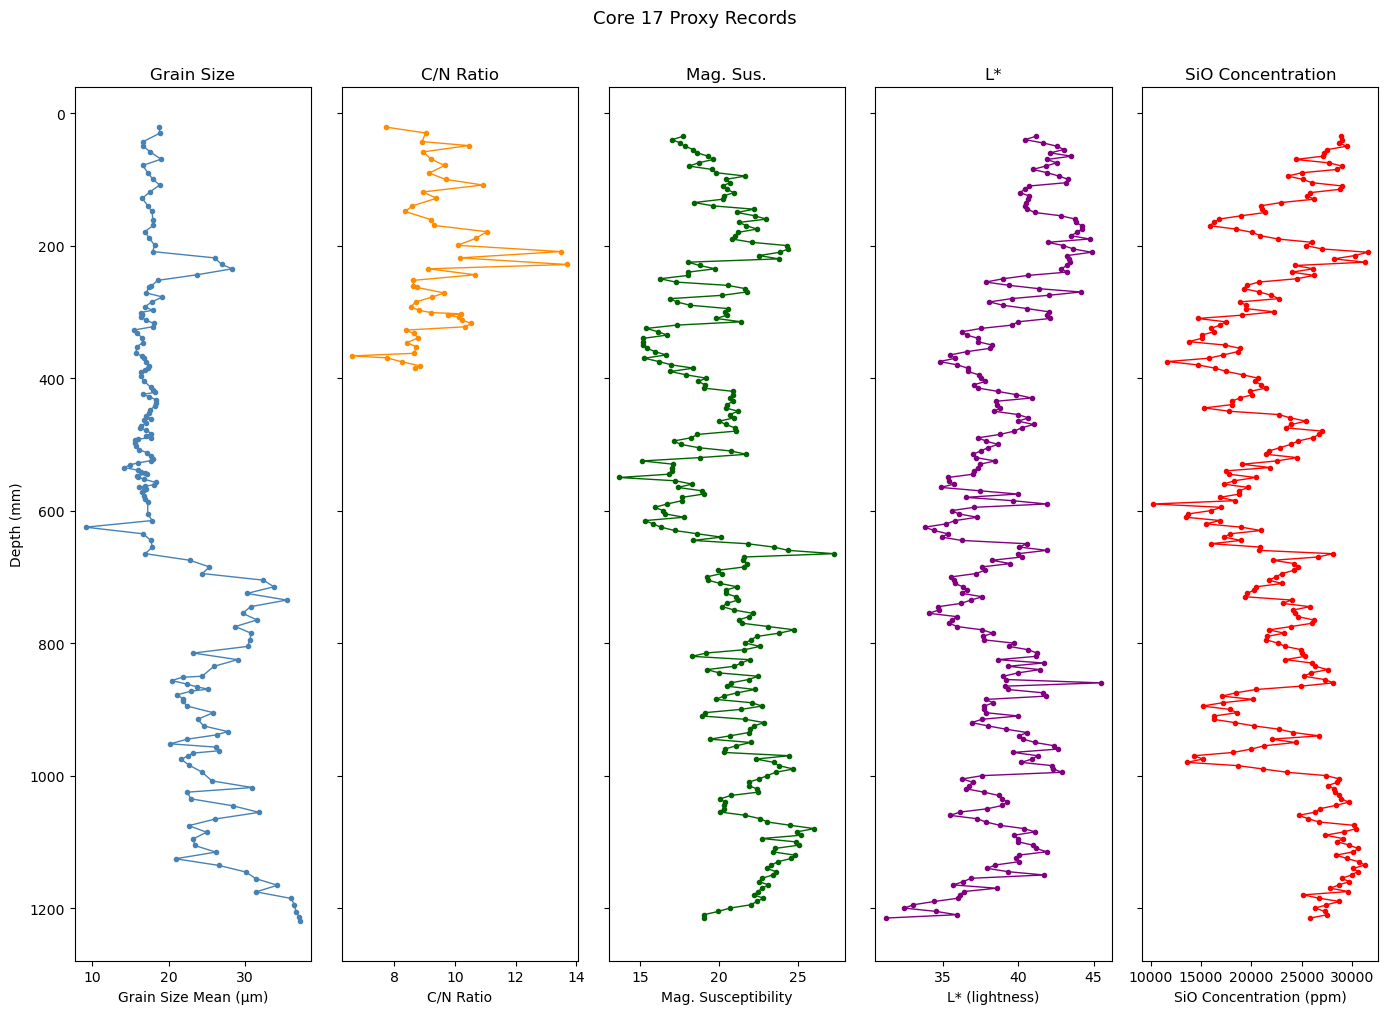

In [52]:
df.columns = [
    'Sample', 'StartDepth', 'EndDepth', 'DepthMidpoint',
    'ParticleWeight', 'CN_Weight', 'Epoch',
    'Mean', 'Sorting', 'Skewness', 'Kurtosis',
    'CN_Ratio',
    'MagDepth', 'MagSus',
    'L_Depth', 'L_star',
    'SIO'
]

# --- Separate proxy dataframes by their own depth columns ---
df_main  = df[['DepthMidpoint', 'Mean', 'CN_Ratio']].dropna(subset=['Mean'])
df_cn    = df[['DepthMidpoint', 'CN_Ratio']].dropna()
df_mag   = df[['MagDepth', 'MagSus']].dropna()
df_lstar = df[['L_Depth', 'L_star']].dropna()
df_sio = df[['MagDepth', 'SIO']].dropna()

# --- Build figure with 4 panels sharing Y axis ---
fig, axes = plt.subplots(1, 5, figsize=(14, 10), sharey=True)

# Panel 1: Grain size mean
axes[0].plot(df_main['Mean'], df_main['DepthMidpoint'], color='steelblue', linewidth=1, marker='o', markersize=3)
axes[0].set_xlabel('Grain Size Mean (µm)')
axes[0].set_ylabel('Depth (mm)')
axes[0].invert_yaxis()
axes[0].set_title('Grain Size')

# Panel 2: C/N Ratio
axes[1].plot(df_cn['CN_Ratio'], df_cn['DepthMidpoint'], color='darkorange', linewidth=1, marker='o', markersize=3)
axes[1].set_xlabel('C/N Ratio')
axes[1].set_title('C/N Ratio')

# Panel 3: Magnetic Susceptibility
axes[2].plot(df_mag['MagSus'], df_mag['MagDepth'], color='darkgreen', linewidth=1, marker='o', markersize=3)
axes[2].set_xlabel('Mag. Susceptibility')
axes[2].set_title('Mag. Sus.')

# Panel 4: L* (lightness)
axes[3].plot(df_lstar['L_star'], df_lstar['L_Depth'], color='purple', linewidth=1, marker='o', markersize=3)
axes[3].set_xlabel('L* (lightness)')
axes[3].set_title('L*')

axes[4].plot(df_sio['SIO'], df_sio['MagDepth'], color='red', linewidth=1, marker='o', markersize=3)
axes[4].set_xlabel('SiO Concentration (ppm)')
axes[4].set_title('SiO Concentration')

plt.suptitle('Core 17 Proxy Records', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('Core17_proxies.png', dpi=150, bbox_inches='tight')
plt.show()

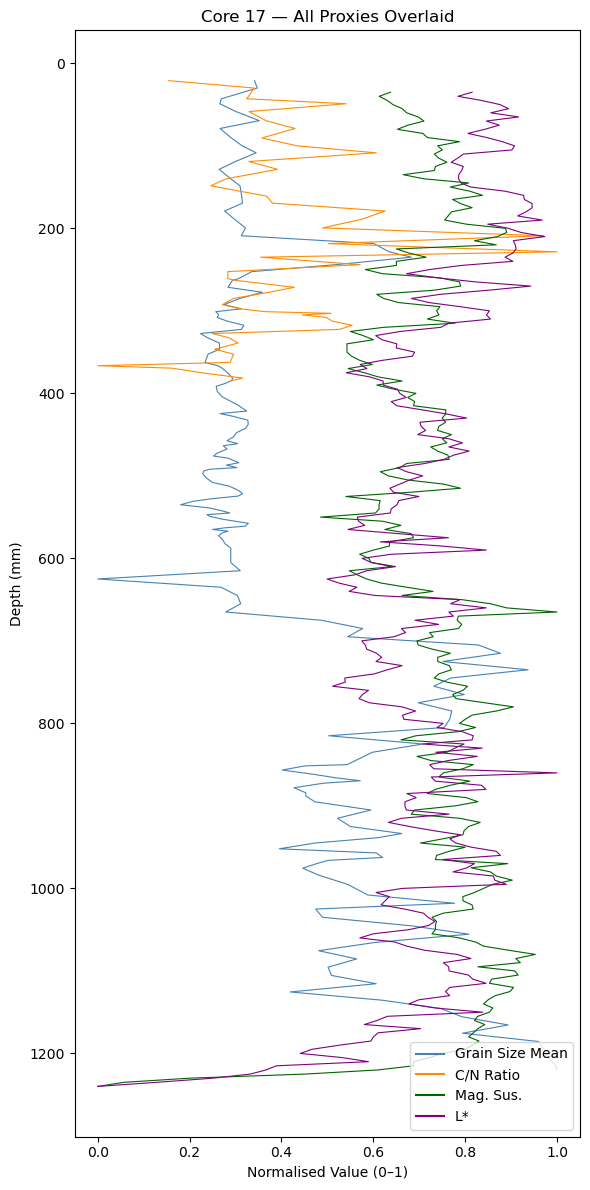

In [28]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

scaler = MinMaxScaler()

# Normalise each proxy to 0-1
df_main['Mean_norm']       = scaler.fit_transform(df_main[['Mean']])
df_cn['CN_norm']           = scaler.fit_transform(df_cn[['CN_Ratio']])
df_mag['Mag_norm']         = scaler.fit_transform(df_mag[['MagSus']])
df_lstar['Lstar_norm']     = scaler.fit_transform(df_lstar[['L_star']])


fig, ax = plt.subplots(figsize=(6, 12))

ax.plot(df_main['Mean_norm'],   df_main['DepthMidpoint'], color='steelblue',  linewidth=0.8, alpha=1)
ax.plot(df_cn['CN_norm'],       df_cn['DepthMidpoint'],   color='darkorange', linewidth=0.8, alpha=1)
ax.plot(df_mag['Mag_norm'],     df_mag['MagDepth'],       color='darkgreen',  linewidth=0.8, alpha=1)
ax.plot(df_lstar['Lstar_norm'], df_lstar['L_Depth'],      color='purple',     linewidth=0.8, alpha=1)

ax.invert_yaxis()
ax.set_ylabel('Depth (mm)')
ax.set_xlabel('Normalised Value (0–1)')
ax.set_title('Core 17 — All Proxies Overlaid')

# Manual legend
handles = [
    mlines.Line2D([], [], color='steelblue',  label='Grain Size Mean'),
    mlines.Line2D([], [], color='darkorange', label='C/N Ratio'),
    mlines.Line2D([], [], color='darkgreen',  label='Mag. Sus.'),
    mlines.Line2D([], [], color='purple',     label='L*'),
]
ax.legend(handles=handles, loc='lower right')

plt.tight_layout()
plt.savefig('Core17_overlaid.png', dpi=150, bbox_inches='tight')
plt.show()

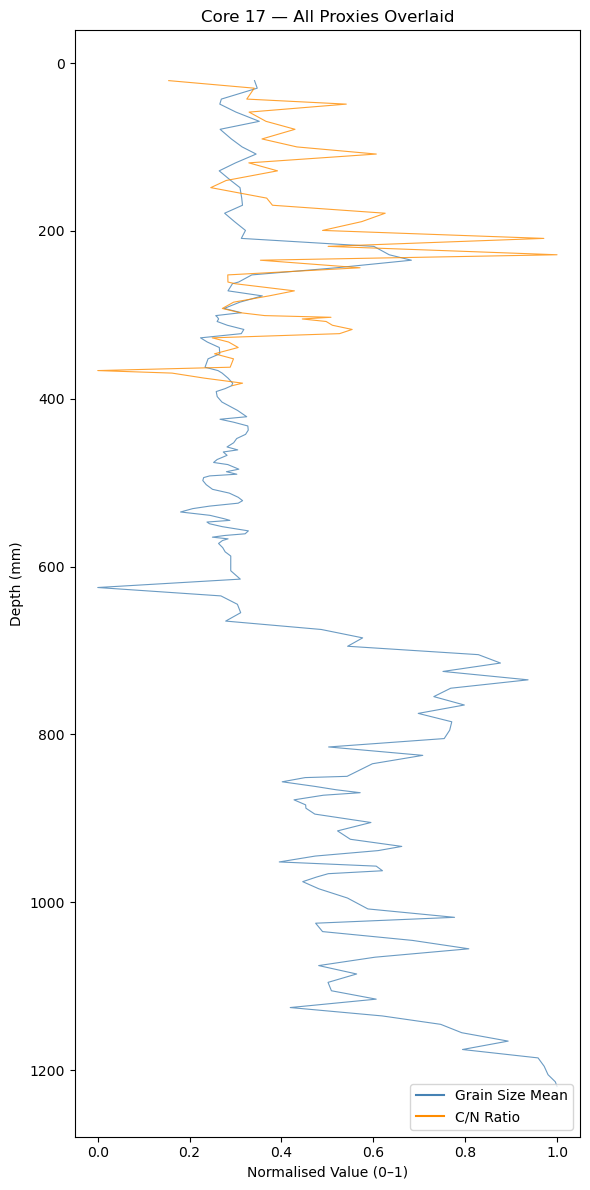

In [12]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

scaler = MinMaxScaler()

# Normalise each proxy to 0-1
df_main['Mean_norm']       = scaler.fit_transform(df_main[['Mean']])
df_cn['CN_norm']           = scaler.fit_transform(df_cn[['CN_Ratio']])

fig, ax = plt.subplots(figsize=(6, 12))

ax.plot(df_main['Mean_norm'],   df_main['DepthMidpoint'], color='steelblue',  linewidth=0.8, alpha=0.8)
ax.plot(df_cn['CN_norm'],       df_cn['DepthMidpoint'],   color='darkorange', linewidth=0.8, alpha=0.8)

ax.invert_yaxis()
ax.set_ylabel('Depth (mm)')
ax.set_xlabel('Normalised Value (0–1)')
ax.set_title('Core 17 — All Proxies Overlaid')

# Manual legend
handles = [
    mlines.Line2D([], [], color='steelblue',  label='Grain Size Mean'),
    mlines.Line2D([], [], color='darkorange', label='C/N Ratio'),
]
ax.legend(handles=handles, loc='lower right')

plt.tight_layout()
plt.savefig('Core17_overlaid.png', dpi=150, bbox_inches='tight')
plt.show()

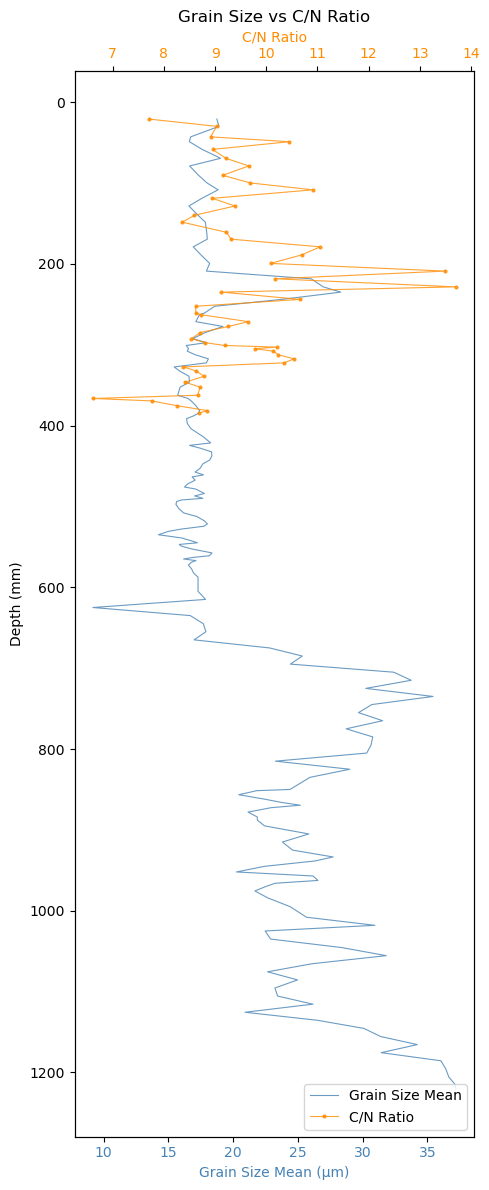

In [14]:
fig, ax1 = plt.subplots(figsize=(5, 12))

# Primary x-axis: Grain Size
ax1.plot(df_main['Mean'], df_main['DepthMidpoint'], color='steelblue', linewidth=0.8, alpha=0.8, label='Grain Size Mean')
ax1.set_xlabel('Grain Size Mean (µm)', color='steelblue')
ax1.tick_params(axis='x', labelcolor='steelblue')
ax1.set_ylabel('Depth (mm)')
ax1.invert_yaxis()

# Secondary x-axis: C/N
ax2 = ax1.twiny()
ax2.plot(df_cn['CN_Ratio'], df_cn['DepthMidpoint'], color='darkorange', linewidth=0.8, alpha=0.8, marker='o', markersize=2, label='C/N Ratio')
ax2.set_xlabel('C/N Ratio', color='darkorange')
ax2.tick_params(axis='x', labelcolor='darkorange')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title('Grain Size vs C/N Ratio')
plt.tight_layout()
plt.savefig('Core17_GSvsCN.png', dpi=150, bbox_inches='tight')
plt.show()

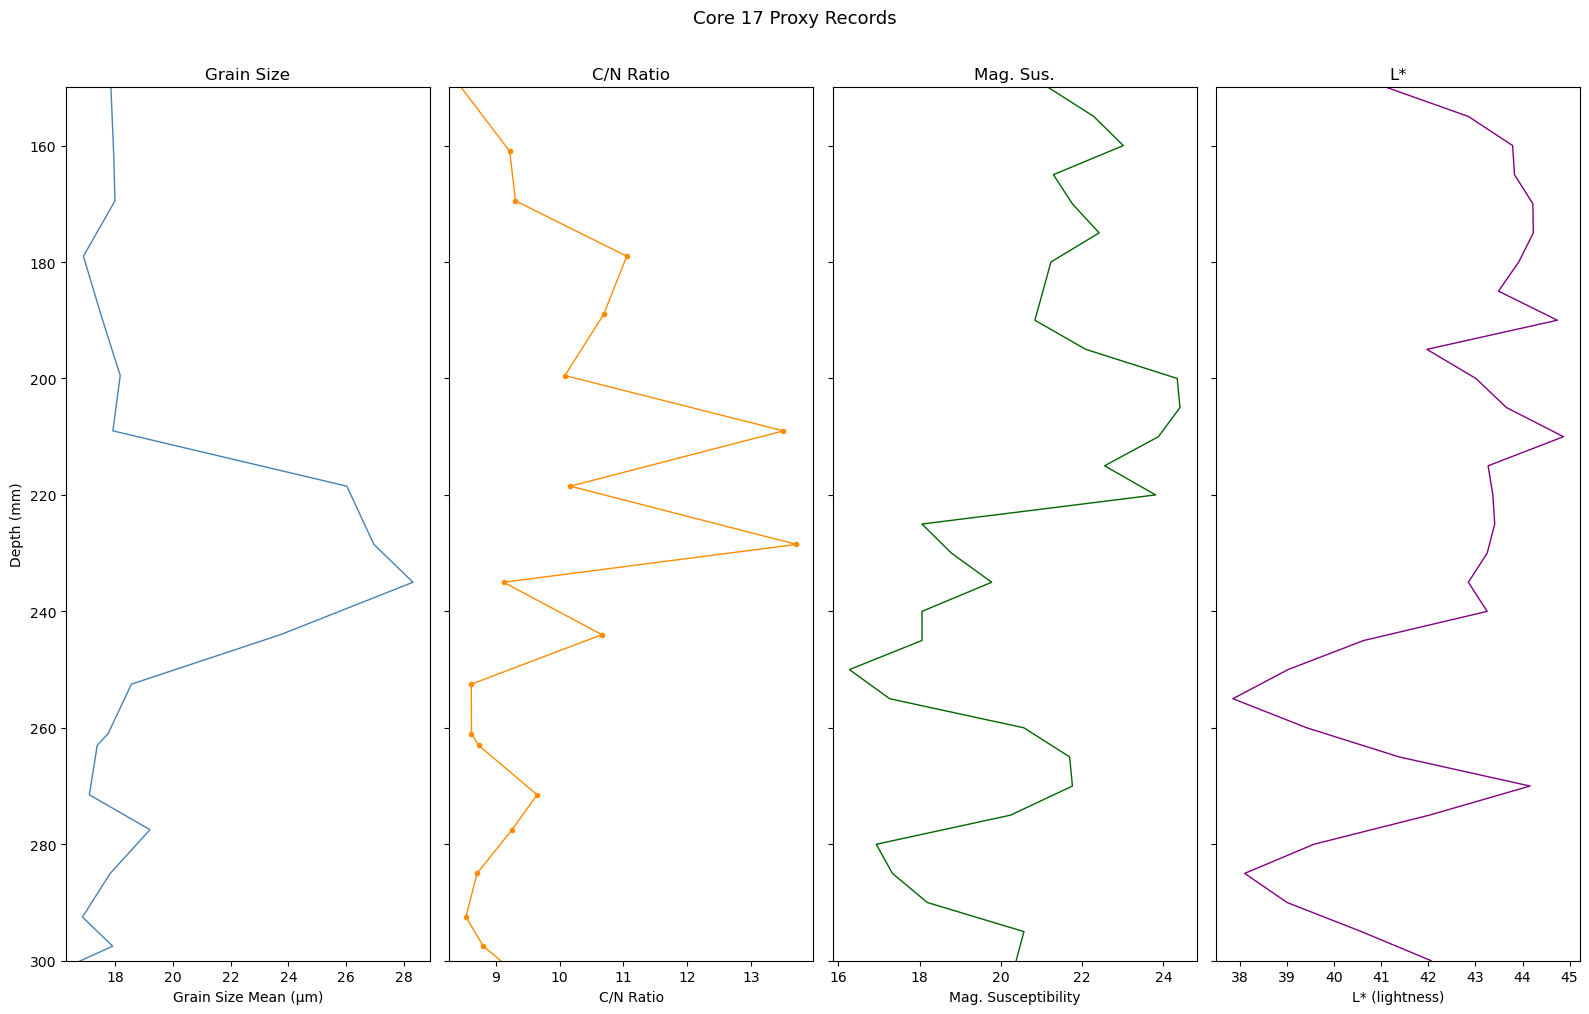

In [50]:
import numpy as np

df.columns = [
    'Sample', 'Depth', 'D2', 'DepthMidpoint',
    'ParticleWeight', 'CN_Weight', 'Epoch',
    'Mean', 'Sorting', 'Skewness', 'Kurtosis',
    'CN_Ratio',
    'MagDepth', 'MagSus',
    'L_Depth', 'L_star',
    'Fe'
]

# ✅ Clean ALL whitespace/non-breaking spaces first, before anything else
df = df.replace(r'^\s+$', np.nan, regex=True)
df = df.replace('\xa0', np.nan, regex=True)

numeric_cols = ['DepthMidpoint', 'Mean', 'Sorting', 'Skewness', 'Kurtosis',
                'CN_Ratio', 'MagDepth', 'MagSus', 'L_Depth', 'L_star', 'Fe']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# --- Separate proxy dataframes by their own depth columns ---
df_main  = df[['DepthMidpoint', 'Mean']].dropna()
df_cn    = df[['DepthMidpoint', 'CN_Ratio']].dropna()
df_mag   = df[['MagDepth', 'MagSus']].dropna()
df_lstar = df[['L_Depth', 'L_star']].dropna()
df_fe    = df[['MagDepth', 'Fe']].dropna()

# --- Build figure with 5 panels sharing Y axis ---
fig, axes = plt.subplots(1, 4, figsize=(16, 10), sharey=True)

# Panel 1: Grain size mean
axes[0].plot(df_main['Mean'], df_main['DepthMidpoint'], color='steelblue', linewidth=1)
axes[0].set_xlabel('Grain Size Mean (µm)')
axes[0].set_ylabel('Depth (mm)')
axes[0].invert_yaxis()
axes[0].set_title('Grain Size')

# Panel 2: C/N Ratio
axes[1].plot(df_cn['CN_Ratio'], df_cn['DepthMidpoint'], color='darkorange', linewidth=1, marker='o', markersize=3)
axes[1].set_xlabel('C/N Ratio')
axes[1].set_title('C/N Ratio')

# Panel 3: Magnetic Susceptibility
axes[2].plot(df_mag['MagSus'], df_mag['MagDepth'], color='darkgreen', linewidth=1)
axes[2].set_xlabel('Mag. Susceptibility')
axes[2].set_title('Mag. Sus.')

# Panel 4: L* (lightness)
axes[3].plot(df_lstar['L_star'], df_lstar['L_Depth'], color='purple', linewidth=1)
axes[3].set_xlabel('L* (lightness)')
axes[3].set_title('L*')


plt.ylim(300,150)

# --- Rescale X axes to only the visible Y window ---
y_min, y_max = axes[0].get_ylim()  # inverted, so y_min > y_max
y_lo = min(y_min, y_max)
y_hi = max(y_min, y_max)

def rescale_x(ax, x_series, y_series):
    mask = (y_series >= y_lo) & (y_series <= y_hi)
    visible_x = x_series[mask]
    if visible_x.empty:
        return
    pad = (visible_x.max() - visible_x.min()) * 0.05  # 5% padding
    ax.set_xlim(visible_x.min() - pad, visible_x.max() + pad)

rescale_x(axes[0], df_main['Mean'],    df_main['DepthMidpoint'])
rescale_x(axes[1], df_cn['CN_Ratio'],  df_cn['DepthMidpoint'])
rescale_x(axes[2], df_mag['MagSus'],   df_mag['MagDepth'])
rescale_x(axes[3], df_lstar['L_star'], df_lstar['L_Depth'])


plt.suptitle('Core 17 Proxy Records', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('Core17_proxies.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
import numpy as np
from scipy import stats
from scipy.interpolate import interp1d

# --- 1. Define a common depth grid ---
# Use the overlapping depth range across all proxies
depth_min = max(df_main['DepthMidpoint'].min(), df_cn['DepthMidpoint'].min(),
                df_mag['MagDepth'].min(),        df_lstar['L_Depth'].min())
depth_max = min(df_main['DepthMidpoint'].max(), df_cn['DepthMidpoint'].max(),
                df_mag['MagDepth'].max(),        df_lstar['L_Depth'].max())

common_depth = np.linspace(depth_min, depth_max, 500)

# --- 2. Interpolate each proxy onto common grid ---
def interp_proxy(depth_col, value_col, grid):
    f = interp1d(depth_col, value_col, bounds_error=False, fill_value=np.nan)
    return f(grid)

grain  = interp_proxy(df_main['DepthMidpoint'],  df_main['Mean'],     common_depth)
cn     = interp_proxy(df_cn['DepthMidpoint'],    df_cn['CN_Ratio'],   common_depth)
magsus = interp_proxy(df_mag['MagDepth'],        df_mag['MagSus'],    common_depth)
lstar  = interp_proxy(df_lstar['L_Depth'],       df_lstar['L_star'],  common_depth)

            Grain Size  C/N Ratio  Mag. Sus.        L*
Grain Size    1.000000   0.507376   0.175929  0.366326
C/N Ratio     0.507376   1.000000   0.493947  0.648641
Mag. Sus.     0.175929   0.493947   1.000000  0.771695
L*            0.366326   0.648641   0.771695  1.000000


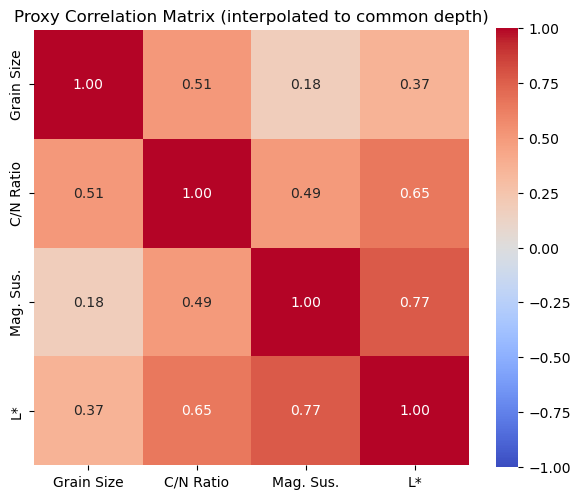

In [54]:
import pandas as pd
import seaborn as sns

# --- 3. Build aligned dataframe ---
df_aligned = pd.DataFrame({
    'Grain Size': grain,
    'C/N Ratio':  cn,
    'Mag. Sus.':  magsus,
    'L*':         lstar,
}, index=common_depth).dropna()

# --- 4. Pearson correlation matrix ---
corr = df_aligned.corr(method='pearson')
print(corr)

# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Proxy Correlation Matrix (interpolated to common depth)')
plt.tight_layout()
plt.savefig('proxy_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

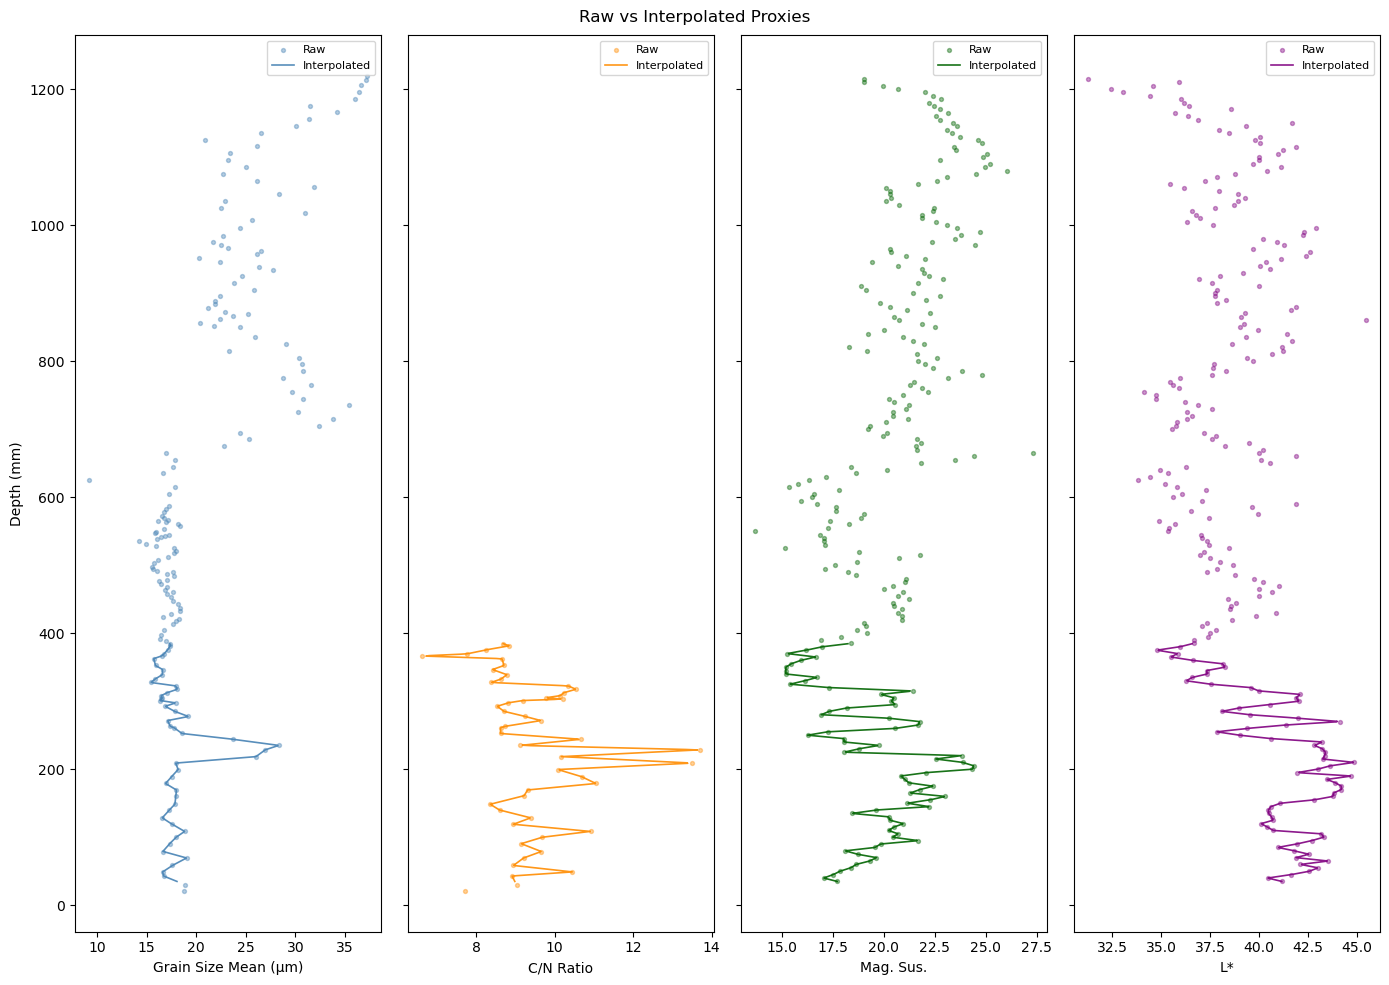

In [55]:
fig, axes = plt.subplots(1, 4, figsize=(14, 10), sharey=True)

proxies = [
    ('Grain Size Mean (µm)', grain,  df_main['DepthMidpoint'],  df_main['Mean'],    'steelblue'),
    ('C/N Ratio',            cn,     df_cn['DepthMidpoint'],    df_cn['CN_Ratio'],  'darkorange'),
    ('Mag. Sus.',            magsus, df_mag['MagDepth'],        df_mag['MagSus'],   'darkgreen'),
    ('L*',                   lstar,  df_lstar['L_Depth'],       df_lstar['L_star'], 'purple'),
]

for ax, (label, interp_vals, raw_depth, raw_vals, color) in zip(axes, proxies):
    # Raw data as scatter
    ax.scatter(raw_vals, raw_depth, color=color, s=8, alpha=0.4, label='Raw')
    # Interpolated as line
    ax.plot(interp_vals, common_depth, color=color, linewidth=1.2, alpha=0.9, label='Interpolated')
    ax.set_xlabel(label)
    ax.invert_yaxis()
    ax.legend(fontsize=8)

axes[0].set_ylabel('Depth (mm)')
plt.suptitle('Raw vs Interpolated Proxies', fontsize=12)
plt.tight_layout()
plt.savefig('proxy_interpolation_check.png', dpi=150, bbox_inches='tight')
plt.show()